# Load data

In [1]:
import numpy as np
import pandas as pd
import torch
from Models import ModelConfig, \
    LinearRegressor, PolynomialRegressor, KNNRegressor, SVMRegressor, \
    DTRegressor, RFRegressor, GBRegressor, ABRegressor, XGBRegressor, LightGBMRegressor, \
    RealMLPRegressor, ResnetRegressor
from sklearn.preprocessing import StandardScaler

print("torch:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

torch: 2.9.1
MPS built: True
MPS available: True


In [2]:
file_name = "CASP"
split_type = "Random_Split"

In [3]:
scaler = StandardScaler()

train_path = f"../data/splitted/{file_name}/{split_type}/train_0.parquet"
df_train = pd.read_parquet(train_path)

df_train = pd.DataFrame(
    scaler.fit_transform(df_train),
    columns = df_train.columns
)

test_path = f"../data/splitted/{file_name}/{split_type}/test_0.parquet"
df_test = pd.read_parquet(test_path)

df_test = pd.DataFrame(
    scaler.transform(df_test),
    columns = df_test.columns
)

In [4]:
config = ModelConfig(
    use_optim = True,
    metric = "rmse",
    n_splits = 3,
    seed = 42
)

# Linear Regression with Huber Loss

In [5]:
regressor = LinearRegressor(df_train, df_test, config = config)

In [6]:
regressor.fit()

In [7]:
regressor.evaluate()

{'MSE': 0.7198404715721793,
 'RMSE': np.float64(0.8484341291886951),
 'MAE': 0.7140888722025637,
 'Adjusted R2 score': 0.2752967163252411}

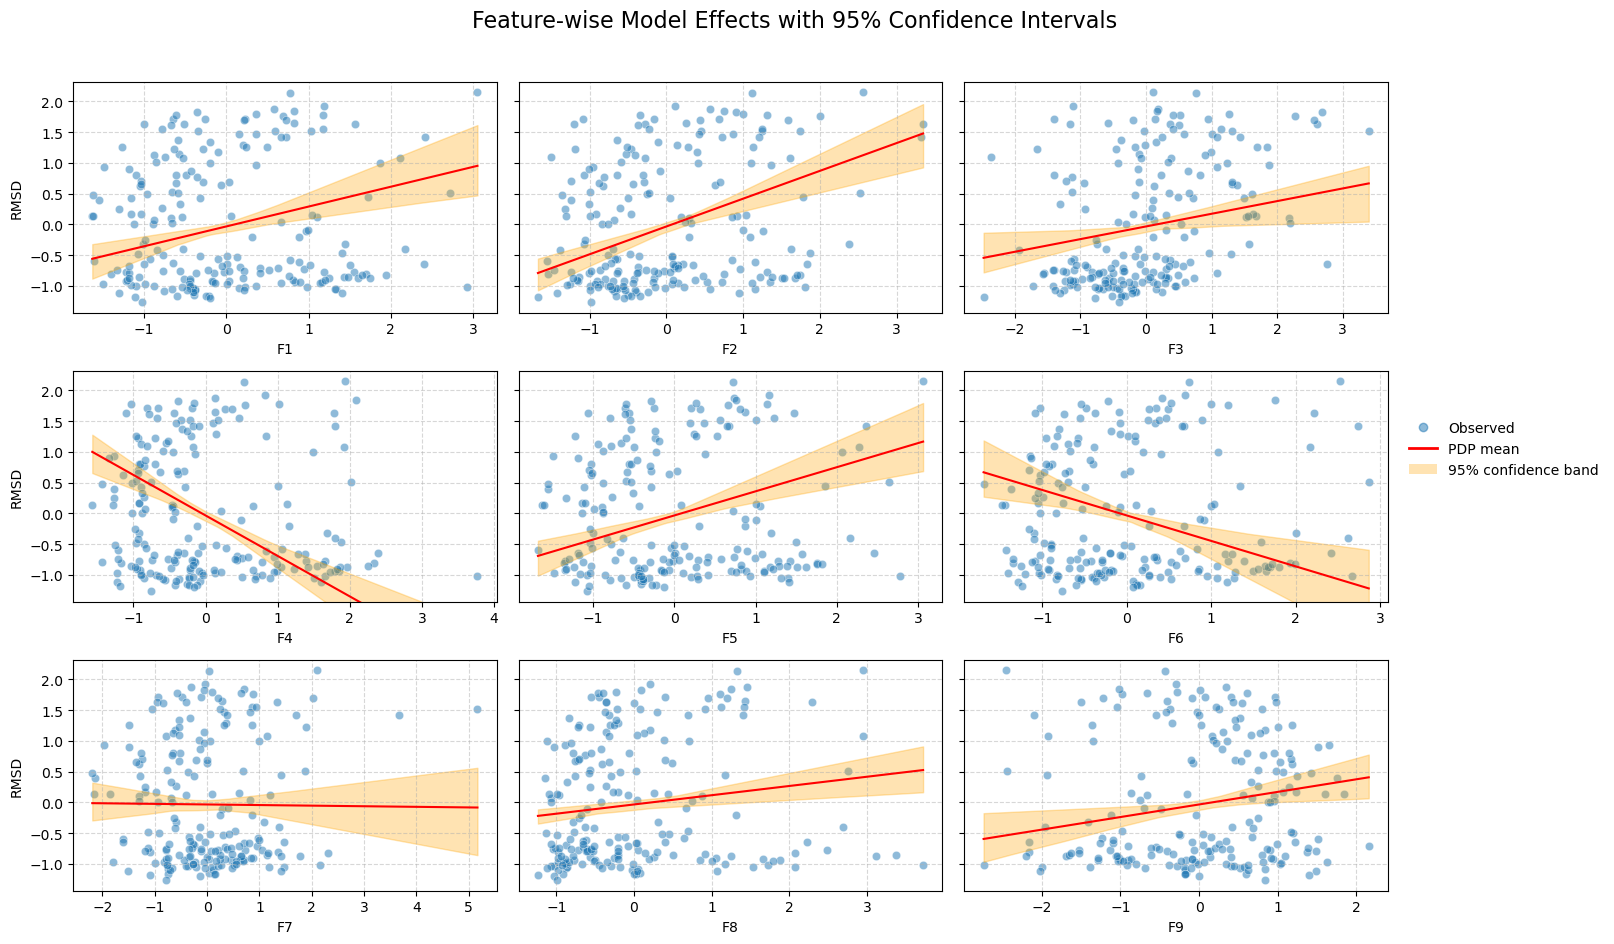

In [8]:
regressor.sketch_model()

# Polynomial Regression

In [9]:
regressor = PolynomialRegressor(df_train, df_test, config = config)

In [10]:
regressor.fit()

In [11]:
regressor.evaluate()

{'MSE': 0.721302905824176,
 'RMSE': np.float64(0.8492955350313435),
 'MAE': 0.7049588037611443,
 'Adjusted R2 score': 0.2738244027412804}

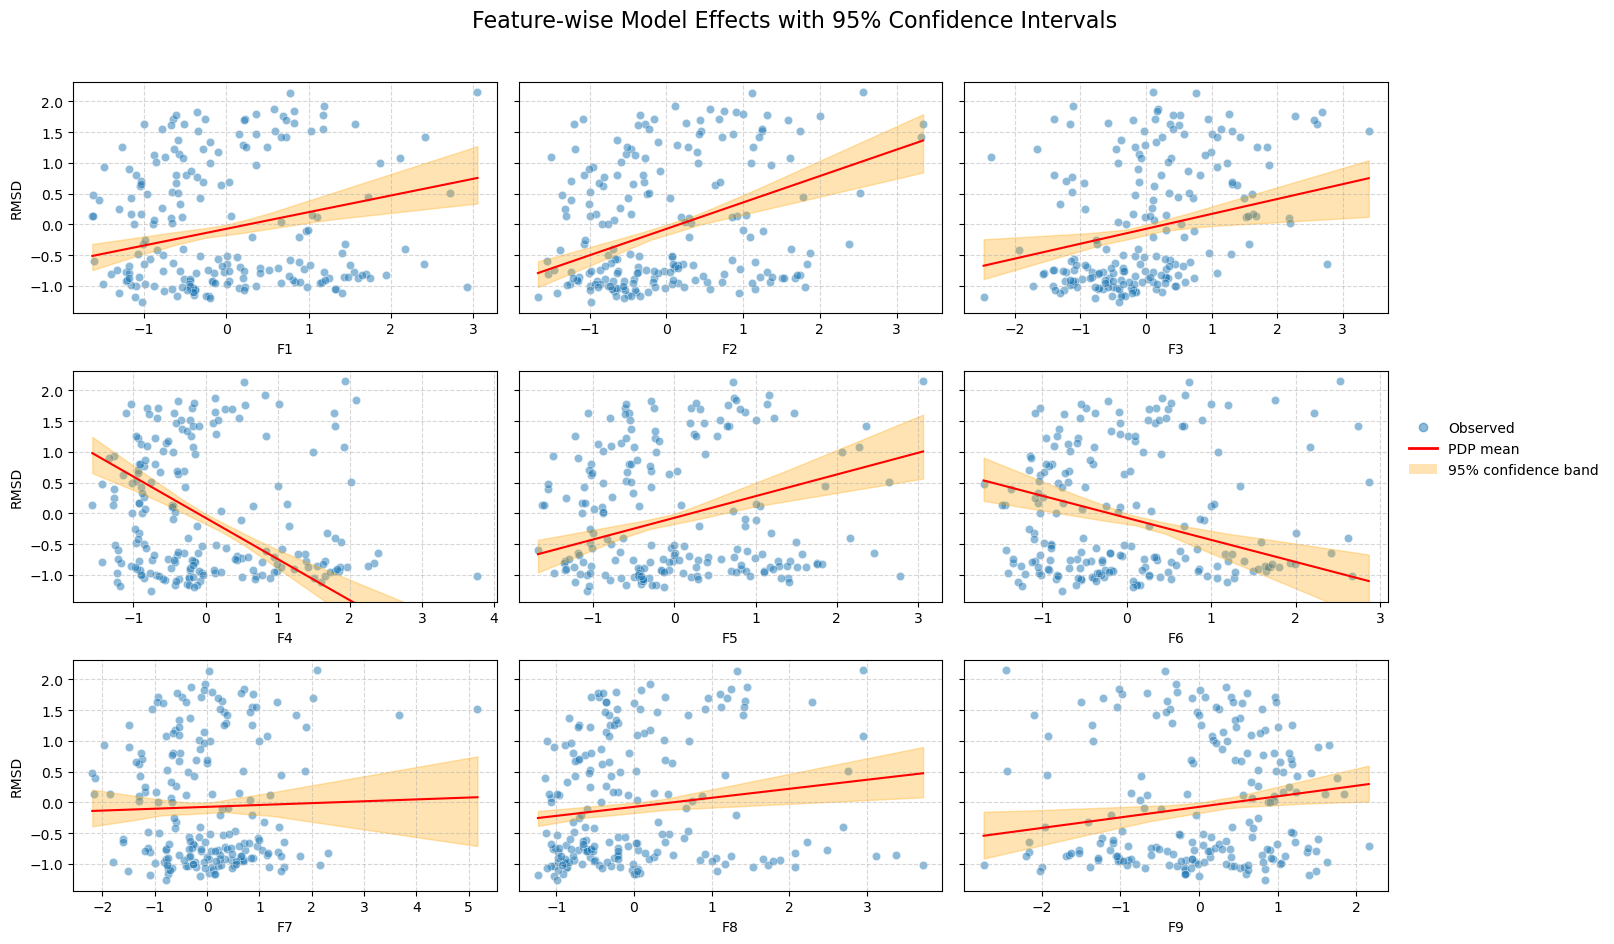

In [12]:
regressor.sketch_model()

# K-Neareast Neighbours Regressor

In [13]:
regressor = KNNRegressor(df_train, df_test, config)

In [14]:
regressor.fit()

In [15]:
regressor.evaluate()

{'MSE': 0.3757042167085024,
 'RMSE': np.float64(0.6129471565383939),
 'MAE': 0.3808464767554385,
 'Adjusted R2 score': 0.6217577500964342}

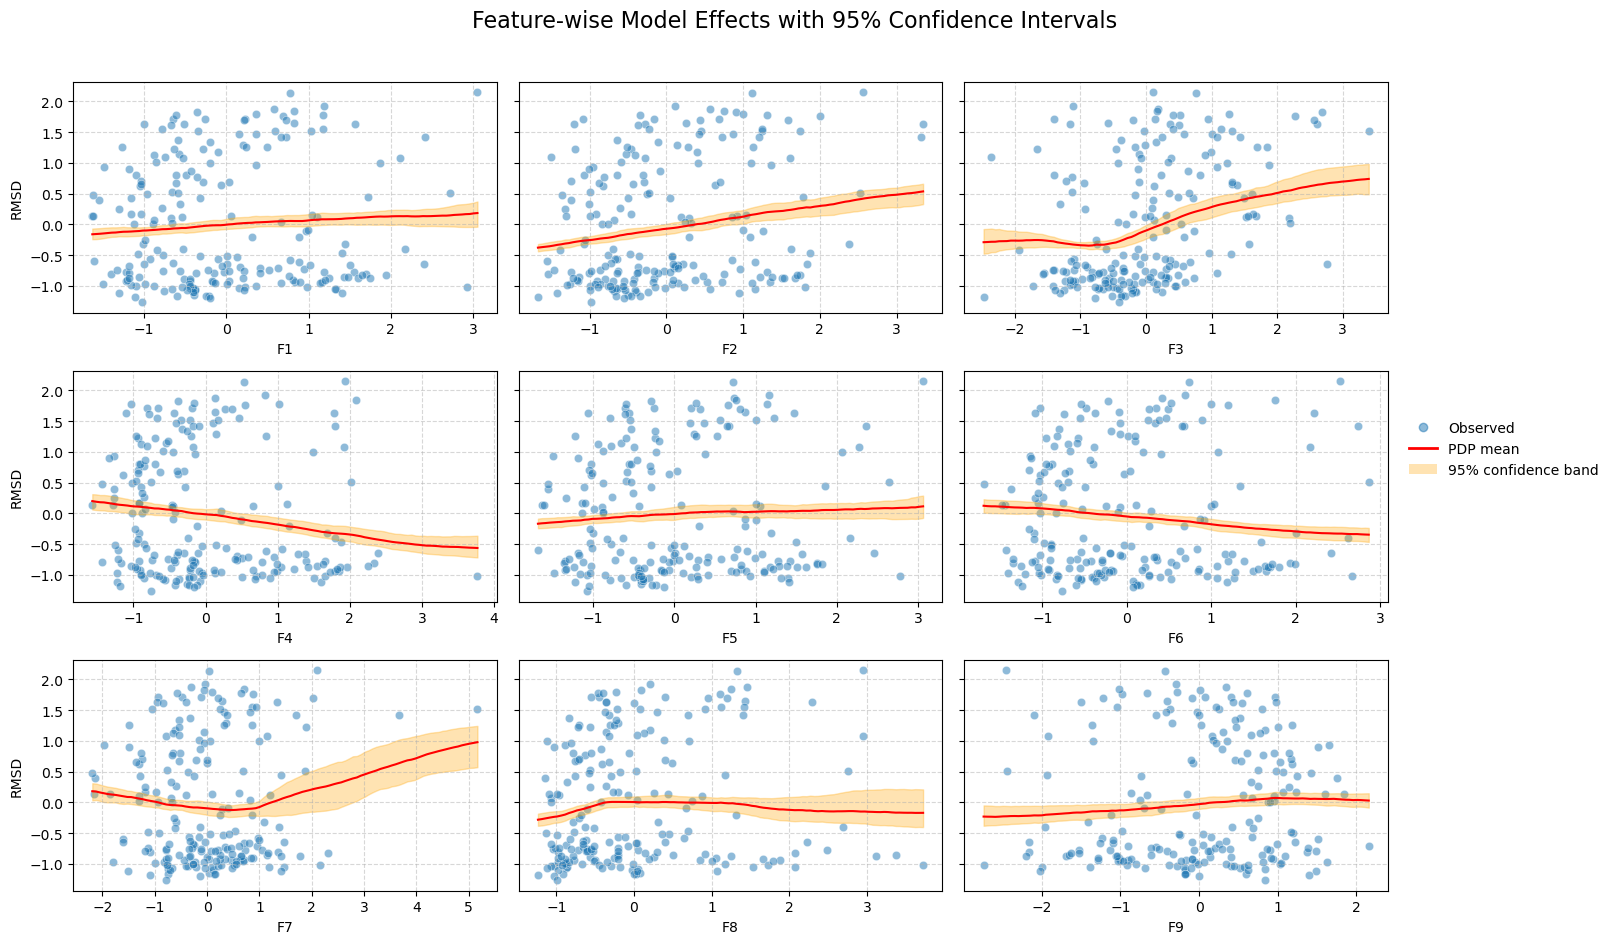

In [16]:
regressor.sketch_model()

# SVM Regressor

In [17]:
regressor = SVMRegressor(df_train, df_test, config)

In [18]:
regressor.fit()

In [19]:
regressor.evaluate()

{'MSE': 0.9885557066667582,
 'RMSE': np.float64(0.9942613874966473),
 'MAE': 0.9135770699109904,
 'Adjusted R2 score': 0.004766201666689507}

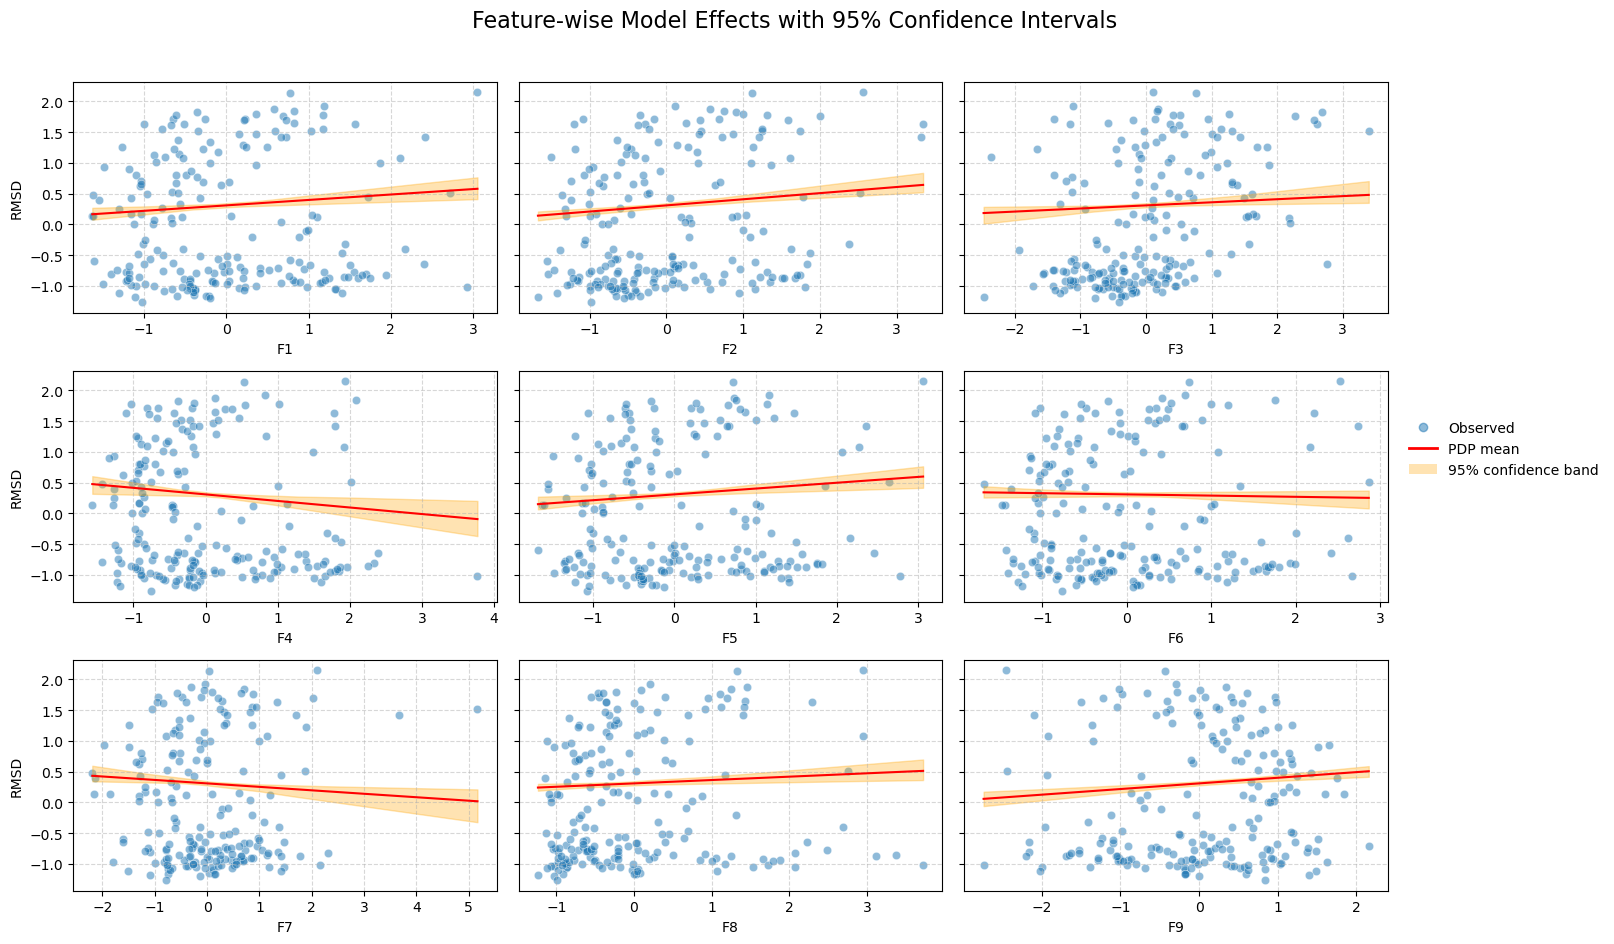

In [20]:
regressor.sketch_model()

# Decision Tree Regressor

In [21]:
regressor = DTRegressor(df_train, df_test, config)

In [22]:
regressor.fit()

In [23]:
regressor.fit()

In [24]:
regressor.evaluate()

{'MSE': 0.5652105990331493,
 'RMSE': np.float64(0.7518048942599066),
 'MAE': 0.5412989228177194,
 'Adjusted R2 score': 0.4309711758877832}

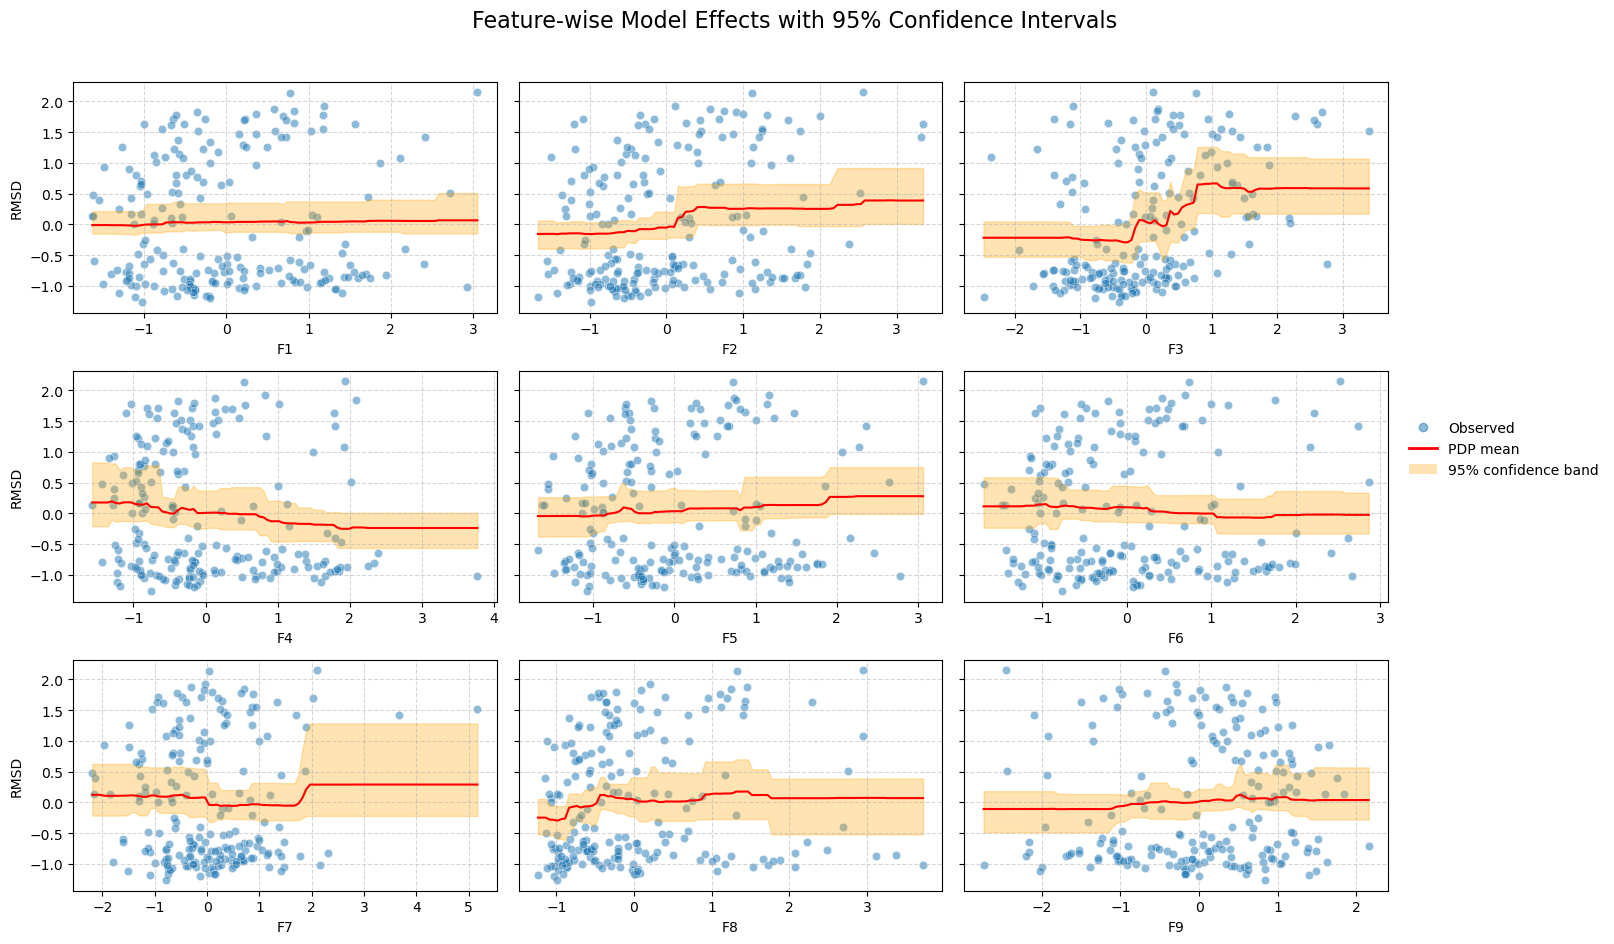

In [25]:
regressor.sketch_model()

# Random Forest Regressor

In [26]:
regressor = RFRegressor(df_train, df_test, config)

In [27]:
regressor.fit()

In [28]:
regressor.evaluate()

{'MSE': 0.4577232792824294,
 'RMSE': np.float64(0.676552495585102),
 'MAE': 0.5202031024536855,
 'Adjusted R2 score': 0.539184615744276}

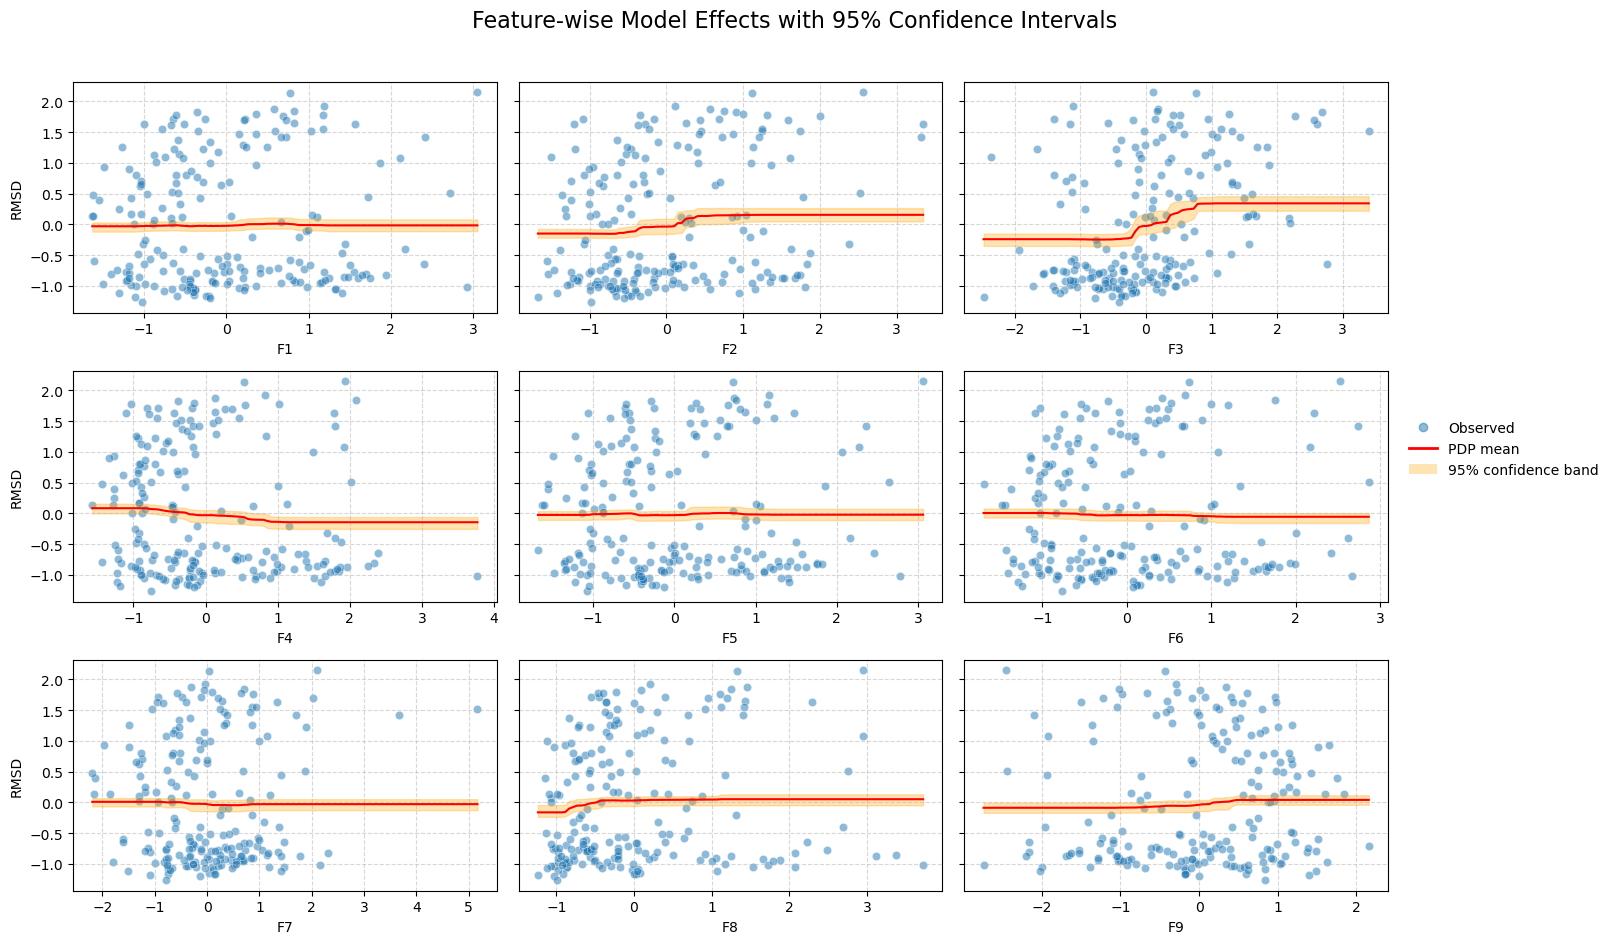

In [29]:
regressor.sketch_model()

# Gradient Boosting Regressor

In [30]:
regressor = GBRegressor(df_train, df_test, config)

In [31]:
regressor.fit()

In [32]:
regressor.evaluate()

{'MSE': 0.3874432222671047,
 'RMSE': np.float64(0.622449373256255),
 'MAE': 0.45562166385428815,
 'Adjusted R2 score': 0.6099394428306385}

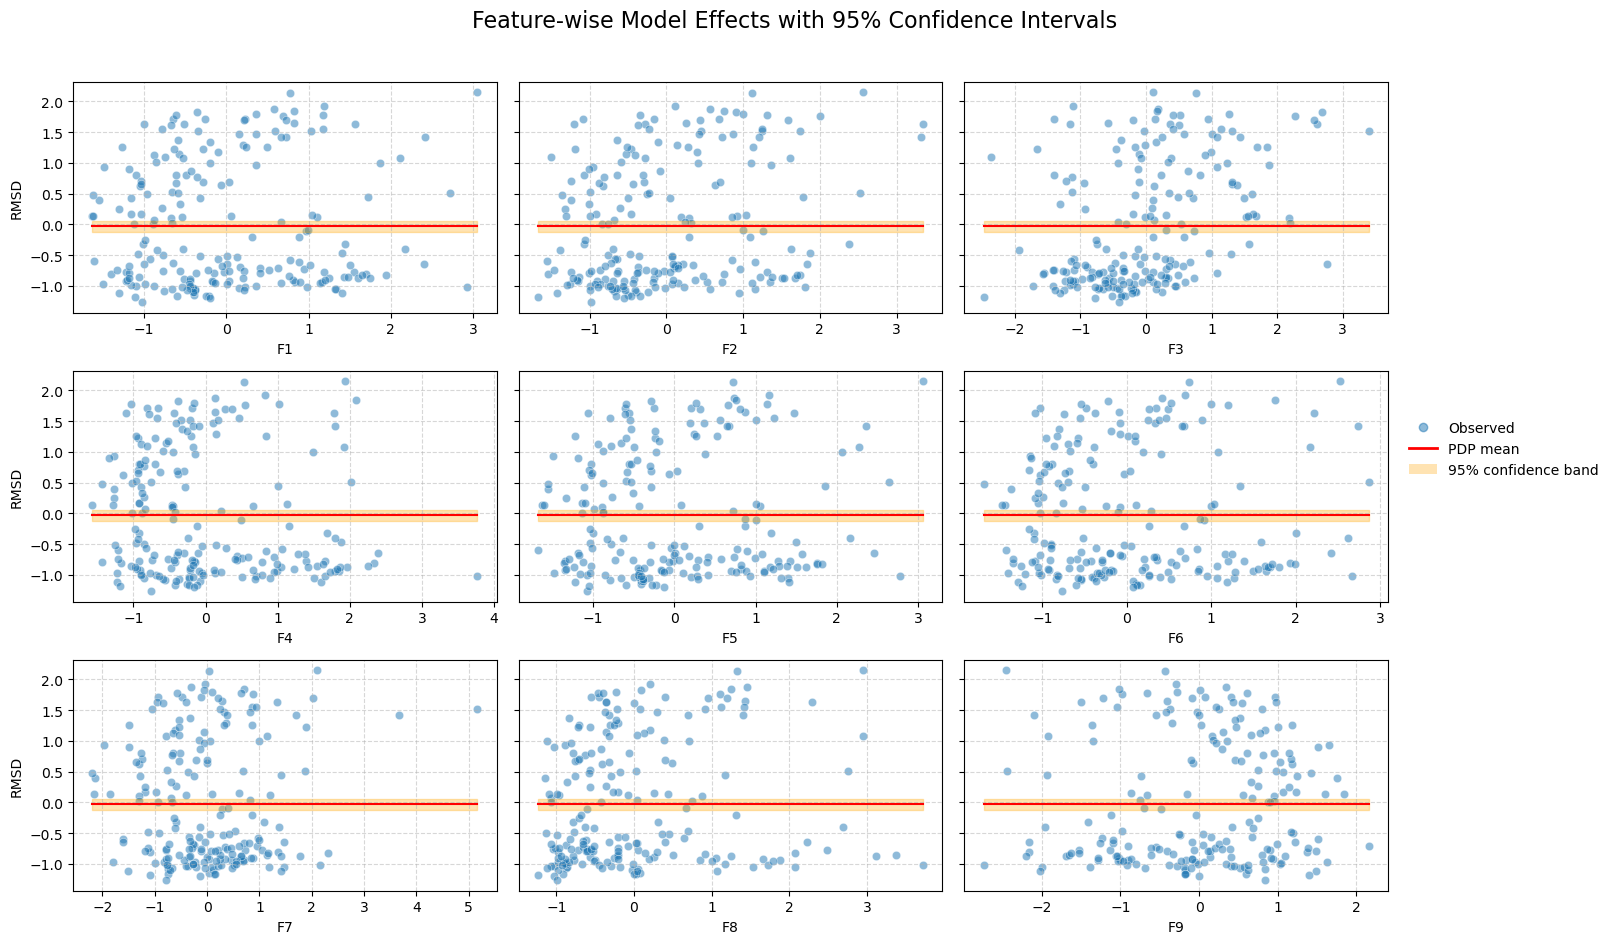

In [33]:
regressor.sketch_model()

# AdaBoost Regressor

The estimator used is Decision Tree, we will optimize hyperparameters of both the estimator and AdaBoost

In [34]:
regressor = ABRegressor(df_train, df_test, config)

In [35]:
regressor.fit()

In [36]:
regressor.evaluate()

{'MSE': 0.7376143262124739,
 'RMSE': np.float64(0.8588447625808019),
 'MAE': 0.7786536520604681,
 'Adjusted R2 score': 0.25740279214333606}

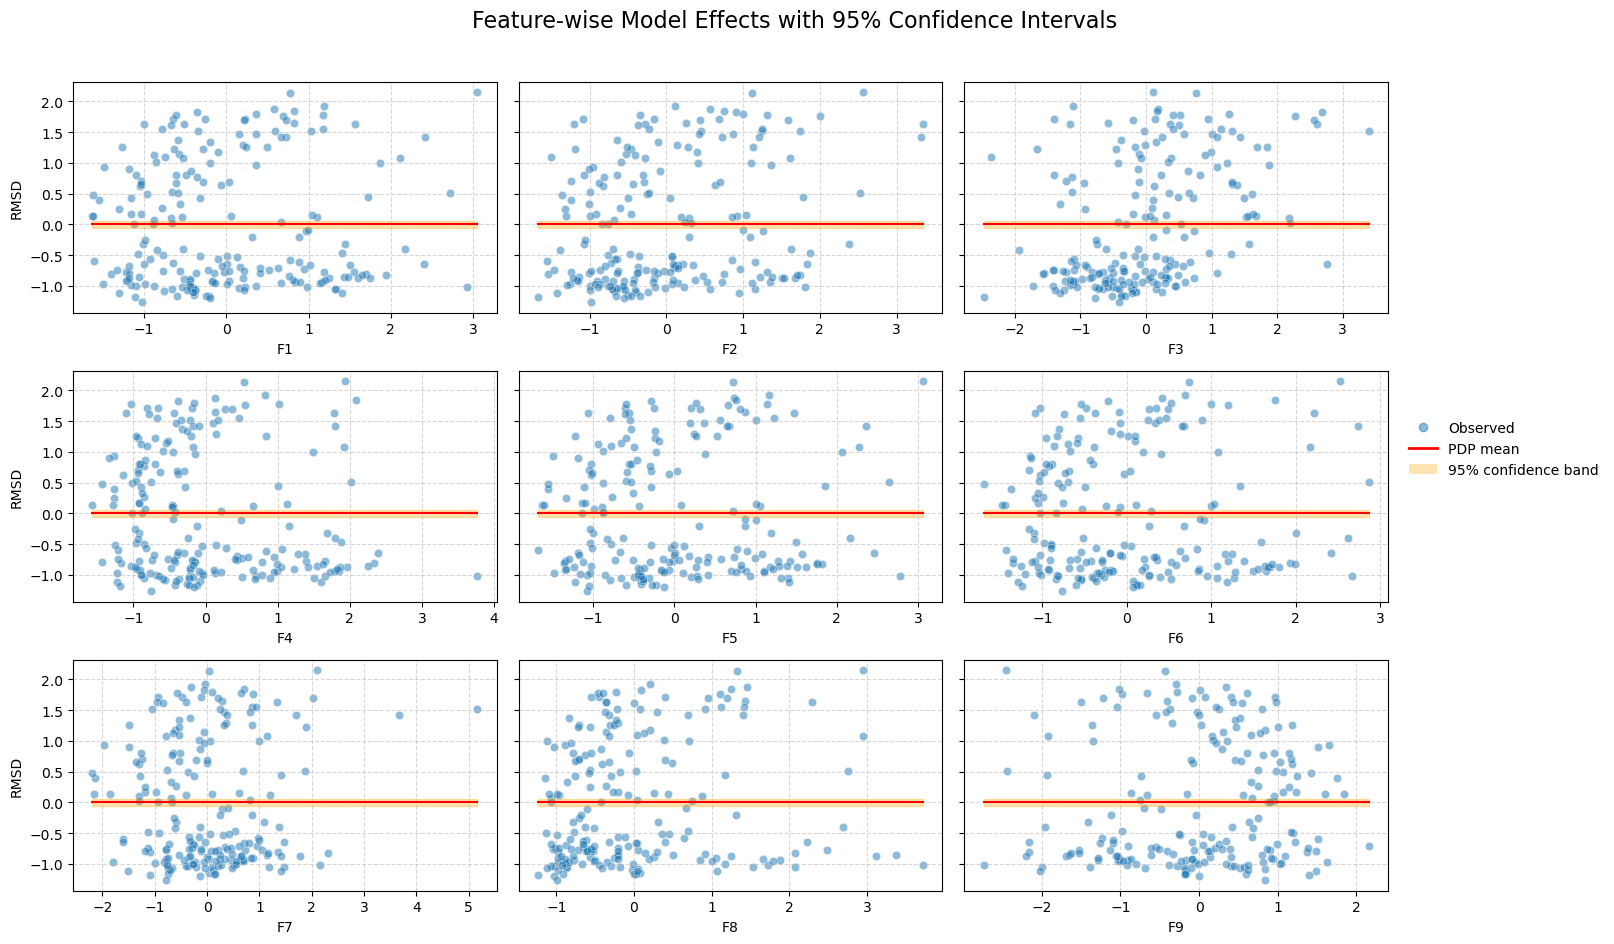

In [37]:
regressor.sketch_model()

# XGBoost Regressor

In [38]:
regressor = XGBRegressor(df_train, df_test, config)

In [39]:
regressor.fit()

In [40]:
regressor.evaluate()

{'MSE': 0.4427795629768782,
 'RMSE': np.float64(0.6654168340047298),
 'MAE': 0.5061210098359684,
 'Adjusted R2 score': 0.5542292828679292}

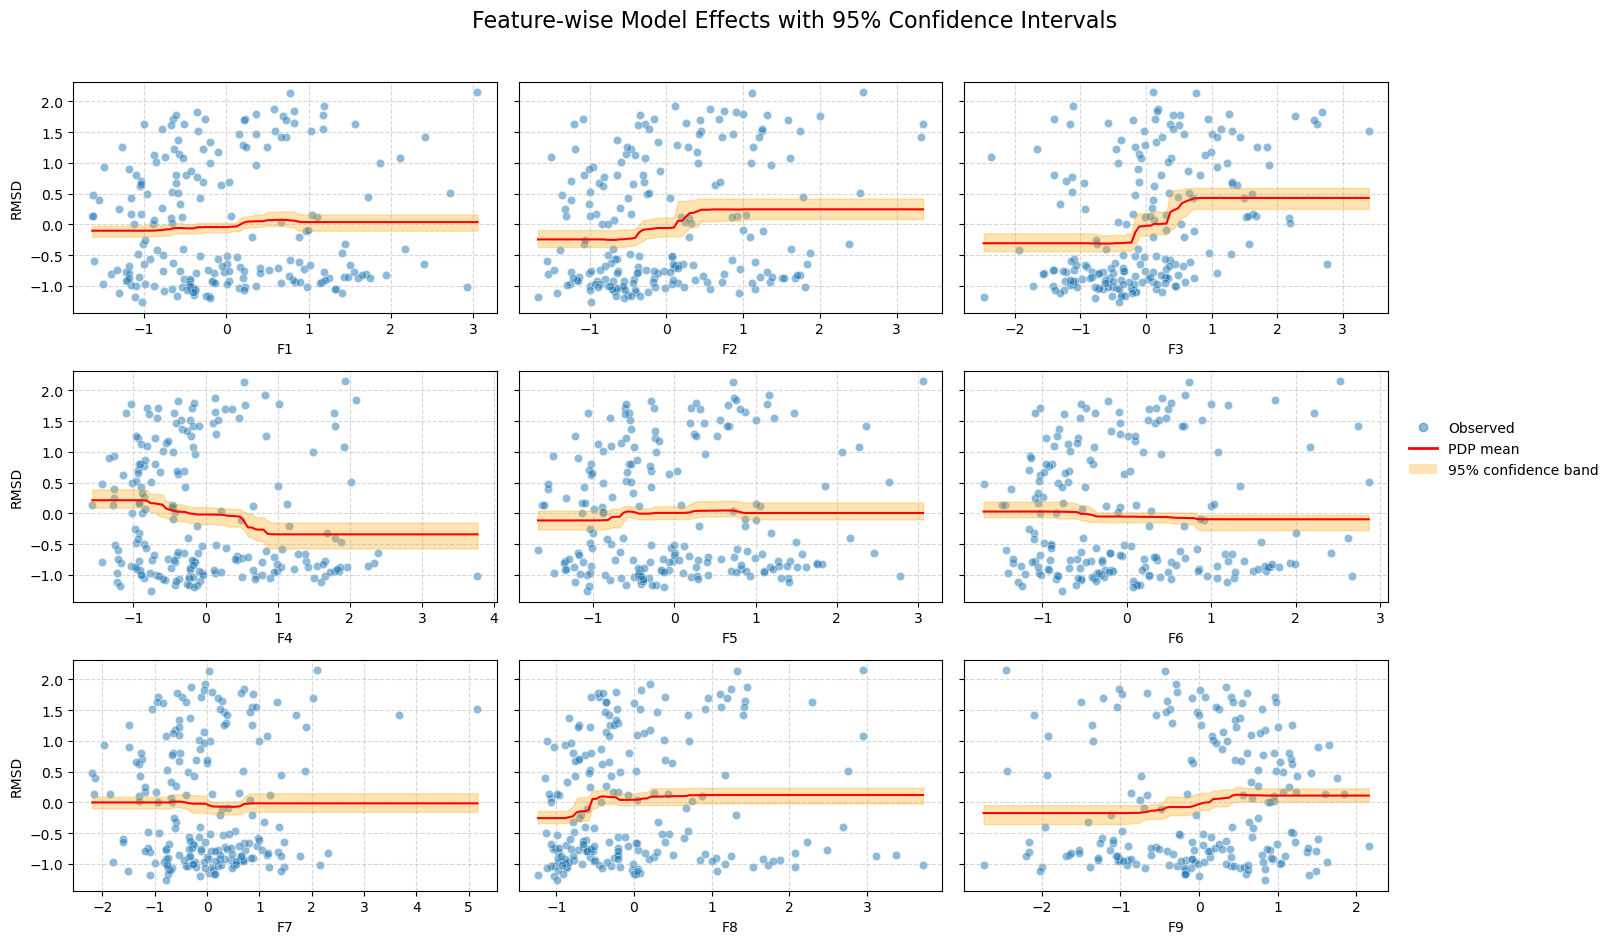

In [41]:
regressor.sketch_model()

# LightGBM Regressor

In [42]:
config.use_optim = False

In [43]:
regressor = LightGBMRegressor(df_train, df_test, config)

In [44]:
regressor.fit()

In [45]:
regressor.evaluate()

{'MSE': 0.33652995038379824,
 'RMSE': np.float64(0.580112015376167),
 'MAE': 0.4068103893019946,
 'Adjusted R2 score': 0.6611966543567873}

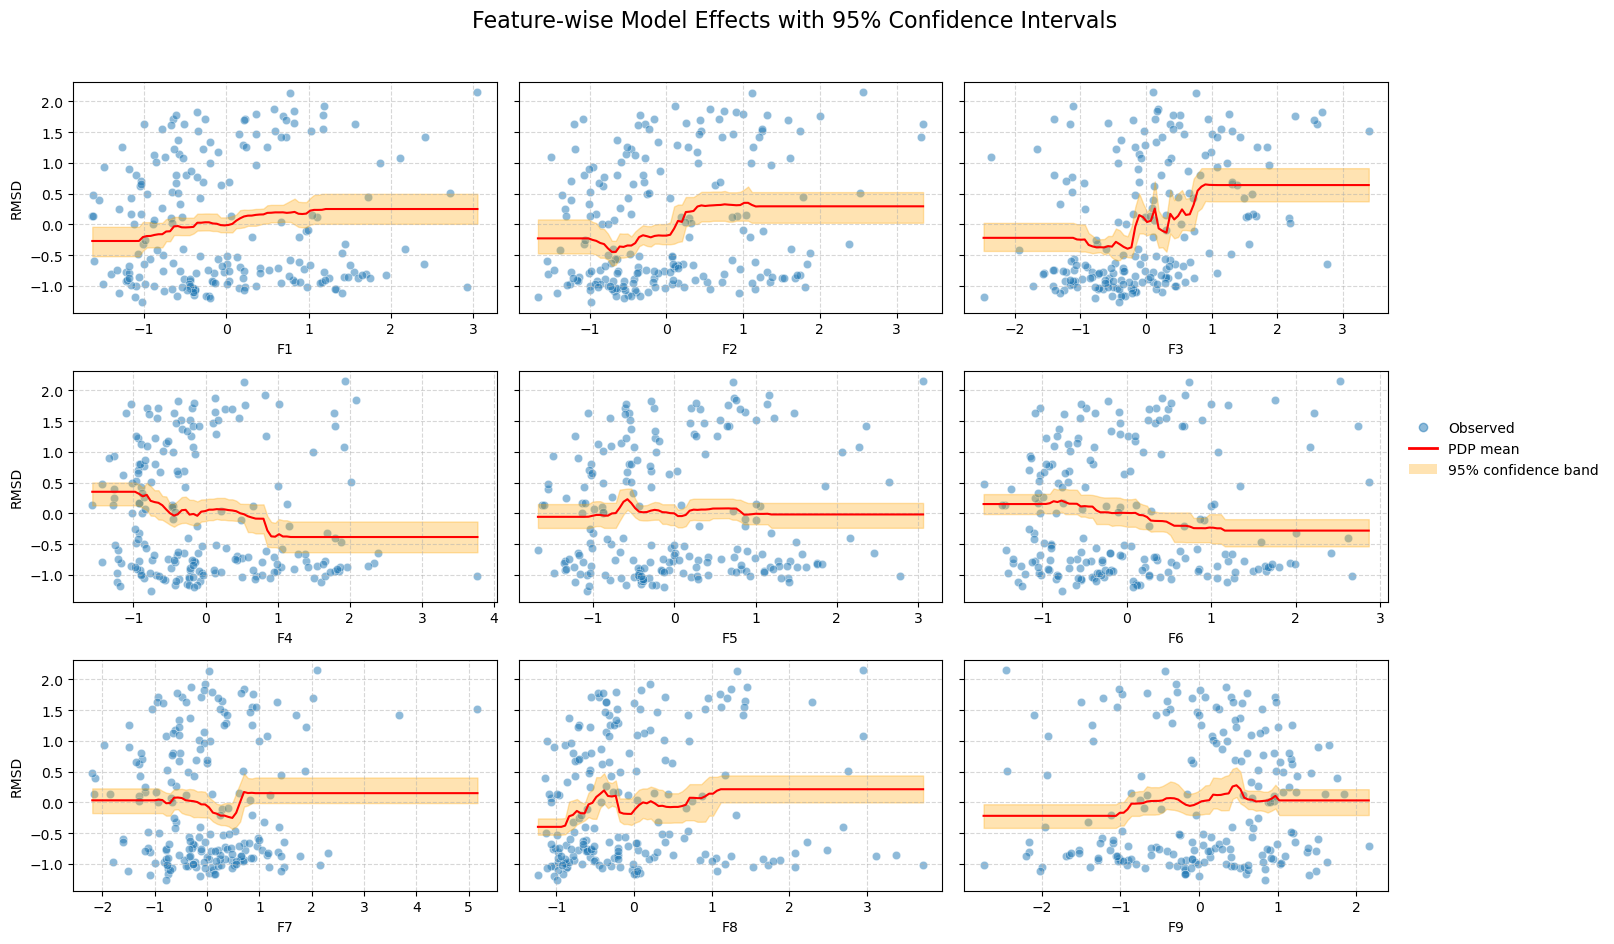

In [46]:
regressor.sketch_model()

# RealMLP Regressor

In [5]:
config.use_optim = False
regressor = RealMLPRegressor(df_train, df_test, config)

In [48]:
regressor.fit()

In [49]:
regressor.evaluate()

{'MSE': 0.3687339066395538,
 'RMSE': np.float64(0.6072346388666854),
 'MAE': 0.40912453060833576,
 'Adjusted R2 score': 0.6287751474152674}

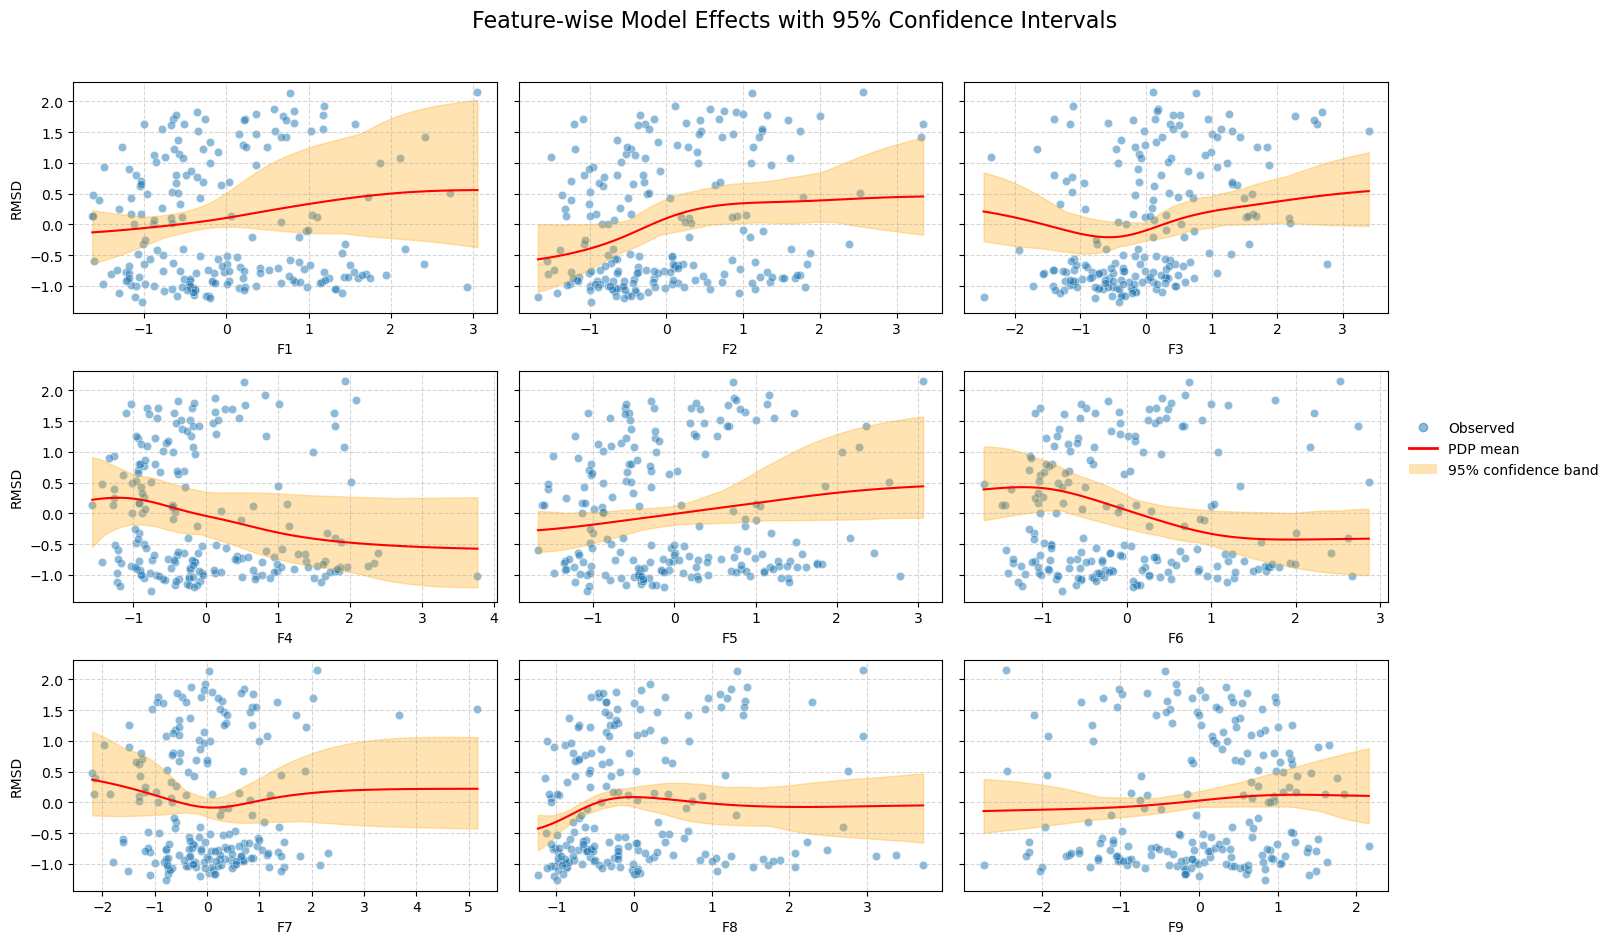

In [6]:
regressor.sketch_model()

# ResNet Regressor

In [5]:
config.use_optim = False
regressor = ResnetRegressor(df_train, df_test, config, d_in = df_train.shape[1] - 1)


EPOCH 10:	Training loss: 0.564	Validation loss: 0.548

EPOCH 20:	Training loss: 0.533	Validation loss: 0.502

EPOCH 30:	Training loss: 0.506	Validation loss: 0.517

EPOCH 40:	Training loss: 0.477	Validation loss: 0.464

EPOCH 50:	Training loss: 0.463	Validation loss: 0.463

EPOCH 60:	Training loss: 0.454	Validation loss: 0.439

EPOCH 70:	Training loss: 0.430	Validation loss: 0.418

EPOCH 80:	Training loss: 0.417	Validation loss: 0.434

EPOCH 90:	Training loss: 0.414	Validation loss: 0.390

EPOCH 100:	Training loss: 0.387	Validation loss: 0.394


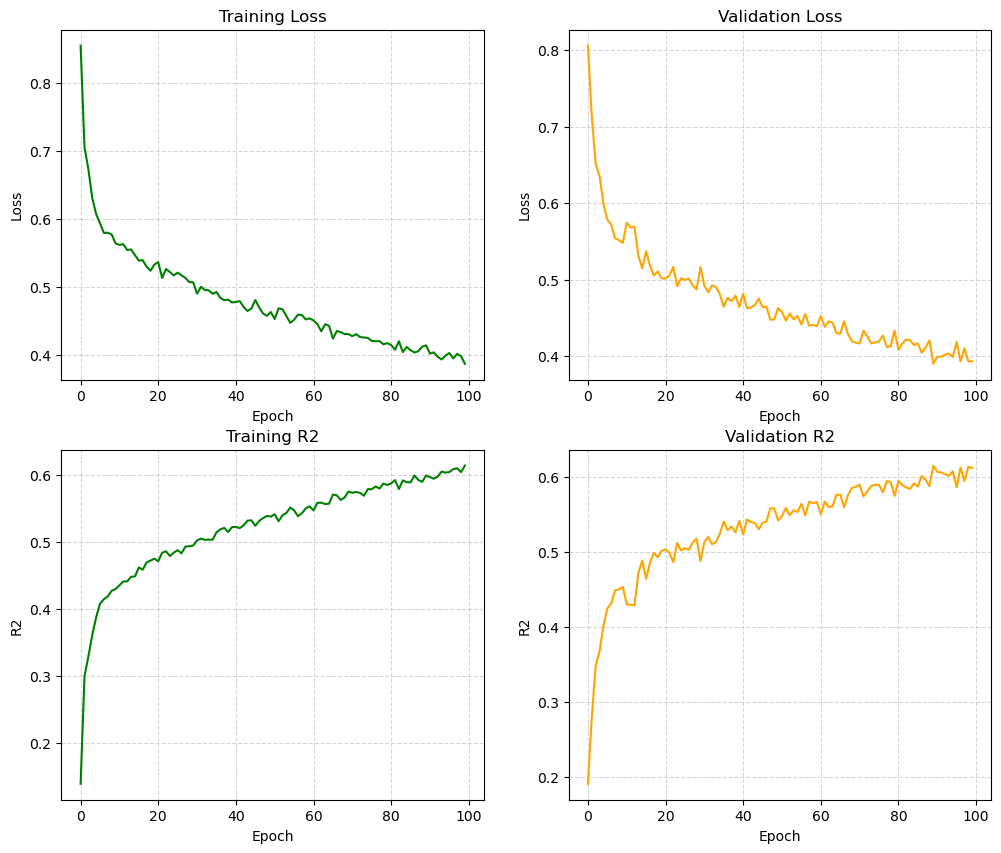

In [6]:
regressor.fit(plot_train_progress = True)

In [7]:
regressor.evaluate()

{'MSE': 0.38077298628063905,
 'RMSE': np.float64(0.6170680564416205),
 'MAE': 0.4300853065235407,
 'Adjusted R2 score': 0.6166547389457895}

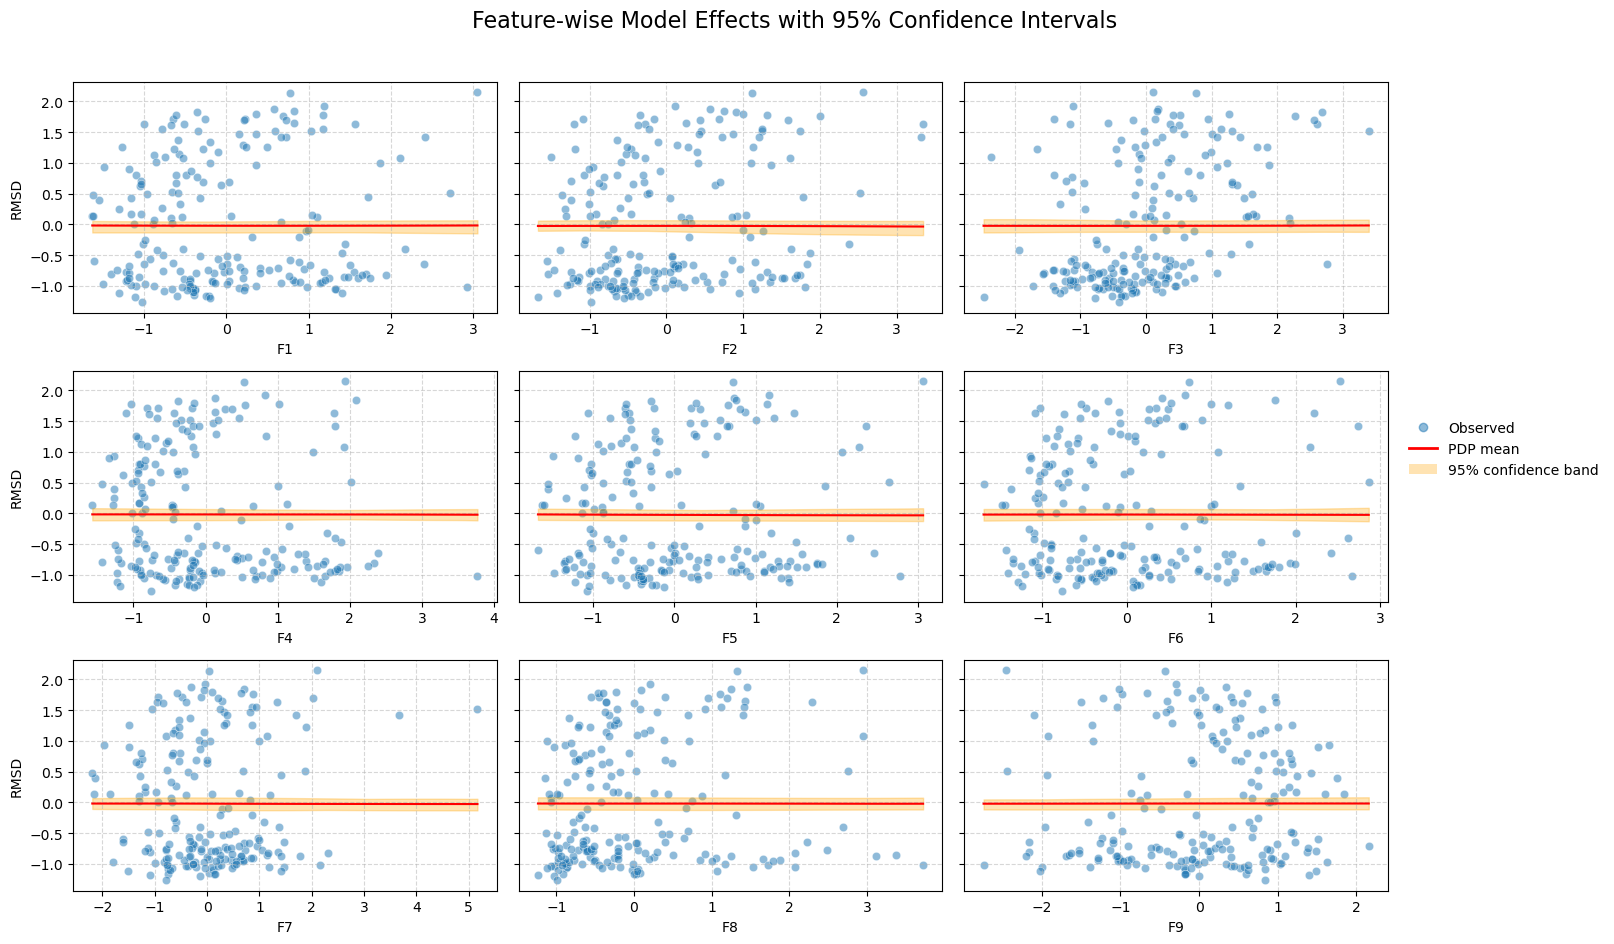

In [8]:
regressor.sketch_model()